Loading Vision Transformer (ViT-GPT2) model weights...


config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model successfully loaded on: cpu

--- Processing Prediction Inference ---


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Original Image Preview:


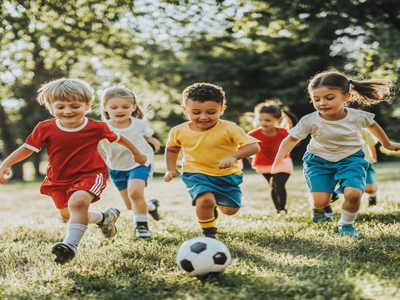


🤖 Generated Caption Output: young children playing soccer on a field


In [2]:
import os
import warnings
from PIL import Image
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

warnings.filterwarnings('ignore')

print("Loading Vision Transformer (ViT-GPT2) model weights...")
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model successfully loaded on: {device}")

max_length = 16
num_beams = 4
gen_kwargs = {"max_length": max_length, "num_beams": num_beams}

def predict_step(image_paths):
    images = []
    for image_path in image_paths:
        if not os.path.exists(image_path):
            print(f"Error: Image file not found at '{image_path}'")
            return None

        i_image = Image.open(image_path)
        if i_image.mode != "RGB":
            i_image = i_image.convert(mode="RGB")
        images.append(i_image)

    pixel_values = feature_extractor(images=images, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    output_ids = model.generate(pixel_values, **gen_kwargs)

    preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    preds = [pred.strip() for pred in preds]
    return preds

target_image = None
possible_names = ['cv_4_image.jpg', 'cv_4_image.png', 'cv_4_image.jpeg']
possible_folders = ['', 'sample_data/']

for folder in possible_folders:
    for name in possible_names:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            target_image = path
            break
    if target_image:
        break

if target_image is None:
    target_image = 'sample_data/cv_4_image.jpg'

if os.path.exists(target_image):
    print("\n--- Processing Prediction Inference ---")
    captions = predict_step([target_image])

    if captions:
        print("Original Image Preview:")
        display(Image.open(target_image).resize((400, 300)))
        print(f"\n Generated Caption Output: {captions[0]}")
else:
    print(f" Error: Could not find 'cv_4_image'. Please upload your image file into the Colab files panel.")